# Visualize HSC and Legacy Survey Images

This notebook loads the preprocessed HDF5 file containing both HSC and Legacy Survey images and visualizes the first examples side by side.


In [8]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Path to preprocessed HDF5 file
HDF5_PATH = '/Users/pablom.perez/Desktop/data/legacysurvey_hsc_crossmatched/preprocessed_hsc_legacy.h5'

# Check if file exists
if not os.path.exists(HDF5_PATH):
    print(f"Error: HDF5 file not found at {HDF5_PATH}")
    print("Please run preprocess_hsc_legacy_images.py first to create the preprocessed dataset.")
else:
    print(f"Found HDF5 file: {HDF5_PATH}")


Found HDF5 file: /Users/pablom.perez/Desktop/data/legacysurvey_hsc_crossmatched/preprocessed_hsc_legacy.h5


In [9]:
# Load and inspect the HDF5 file
with h5py.File(HDF5_PATH, 'r') as f:
    # Get metadata (store as global variables for use in later cells)
    num_images = f.attrs.get('num_images', None)
    crop_size = f.attrs.get('crop_size', None)
    num_channels = f.attrs.get('num_channels', None)
    hsc_bands = f.attrs.get('hsc_bands', None)
    legacy_bands = f.attrs.get('legacy_bands', None)

    # Get dataset shapes
    hsc_shape = f['hsc_images'].shape if 'hsc_images' in f else None
    legacy_shape = f['legacy_images'].shape if 'legacy_images' in f else None

    print("=" * 60)
    print("HDF5 File Information")
    print("=" * 60)
    print(f"Path: {HDF5_PATH}")
    print()
    print(f"Number of images: {num_images}")
    print(f"Crop size: {crop_size}")
    print(f"Number of channels: {num_channels}")
    print(f"HSC bands: {hsc_bands}")
    print(f"Legacy bands: {legacy_bands}")
    print()
    if hsc_shape:
        print(f"HSC images shape: {hsc_shape}")
    if legacy_shape:
        print(f"Legacy images shape: {legacy_shape}")
    print("=" * 60)


HDF5 File Information
Path: /Users/pablom.perez/Desktop/data/legacysurvey_hsc_crossmatched/preprocessed_hsc_legacy.h5

Number of images: None
Crop size: None
Number of channels: None
HSC bands: None
Legacy bands: None

HSC images shape: (10280, 4, 96, 96)
Legacy images shape: (10280, 4, 96, 96)


In [10]:
def convert_to_rgb(image_4ch):
    """
    Convert 4-channel (g, r, i, z) image to RGB using first 3 channels.

    Args:
        image_4ch: Image with shape (4, H, W) or (H, W, 4)

    Returns:
        RGB image with shape (H, W, 3)
    """
    if len(image_4ch.shape) == 3 and image_4ch.shape[0] == 4:
        # Shape is (4, H, W)
        rgb = np.stack([
            image_4ch[0],  # g -> R
            image_4ch[1],  # r -> G
            image_4ch[2]   # i -> B
        ], axis=-1)  # (H, W, 3)
    elif len(image_4ch.shape) == 3 and image_4ch.shape[2] == 4:
        # Shape is (H, W, 4)
        rgb = np.stack([
            image_4ch[:, :, 0],  # g -> R
            image_4ch[:, :, 1],  # r -> G
            image_4ch[:, :, 2]   # i -> B
        ], axis=-1)  # (H, W, 3)
    else:
        raise ValueError(f"Unexpected image shape: {image_4ch.shape}")

    # Normalize each channel to [0, 1] for visualization
    for c in range(3):
        ch = rgb[:, :, c]
        ch_min, ch_max = ch.min(), ch.max()
        if ch_max > ch_min:
            rgb[:, :, c] = (ch - ch_min) / (ch_max - ch_min)
        else:
            rgb[:, :, c] = 0

    return rgb


In [11]:
# Load first N examples
num_examples = 8

with h5py.File(HDF5_PATH, 'r') as f:
    # Load first num_examples images
    hsc_images = f['hsc_images'][:num_examples]  # (N, 4, 96, 96)
    legacy_images = f['legacy_images'][:num_examples]  # (N, 4, 96, 96)
    indices = f['indices'][:num_examples]  # (N,)

    print(f"Loaded {num_examples} image pairs")
    print(f"HSC images shape: {hsc_images.shape}")
    print(f"Legacy images shape: {legacy_images.shape}")
    print(f"Indices: {indices}")

    # Print statistics
    print(f"\nHSC Images Statistics:")
    print(f"  Min: {hsc_images.min():.6f}, Max: {hsc_images.max():.6f}")
    print(f"  Mean: {hsc_images.mean():.6f}, Std: {hsc_images.std():.6f}")

    print(f"\nLegacy Images Statistics:")
    print(f"  Min: {legacy_images.min():.6f}, Max: {legacy_images.max():.6f}")
    print(f"  Mean: {legacy_images.mean():.6f}, Std: {legacy_images.std():.6f}")


Loaded 8 image pairs
HSC images shape: (8, 4, 96, 96)
Legacy images shape: (8, 4, 96, 96)
Indices: [0 1 2 3 4 5 6 7]

HSC Images Statistics:
  Min: -0.040207, Max: 0.442178
  Mean: 0.007763, Std: 0.030712

Legacy Images Statistics:
  Min: -0.172068, Max: 0.518313
  Mean: 0.007422, Std: 0.043559


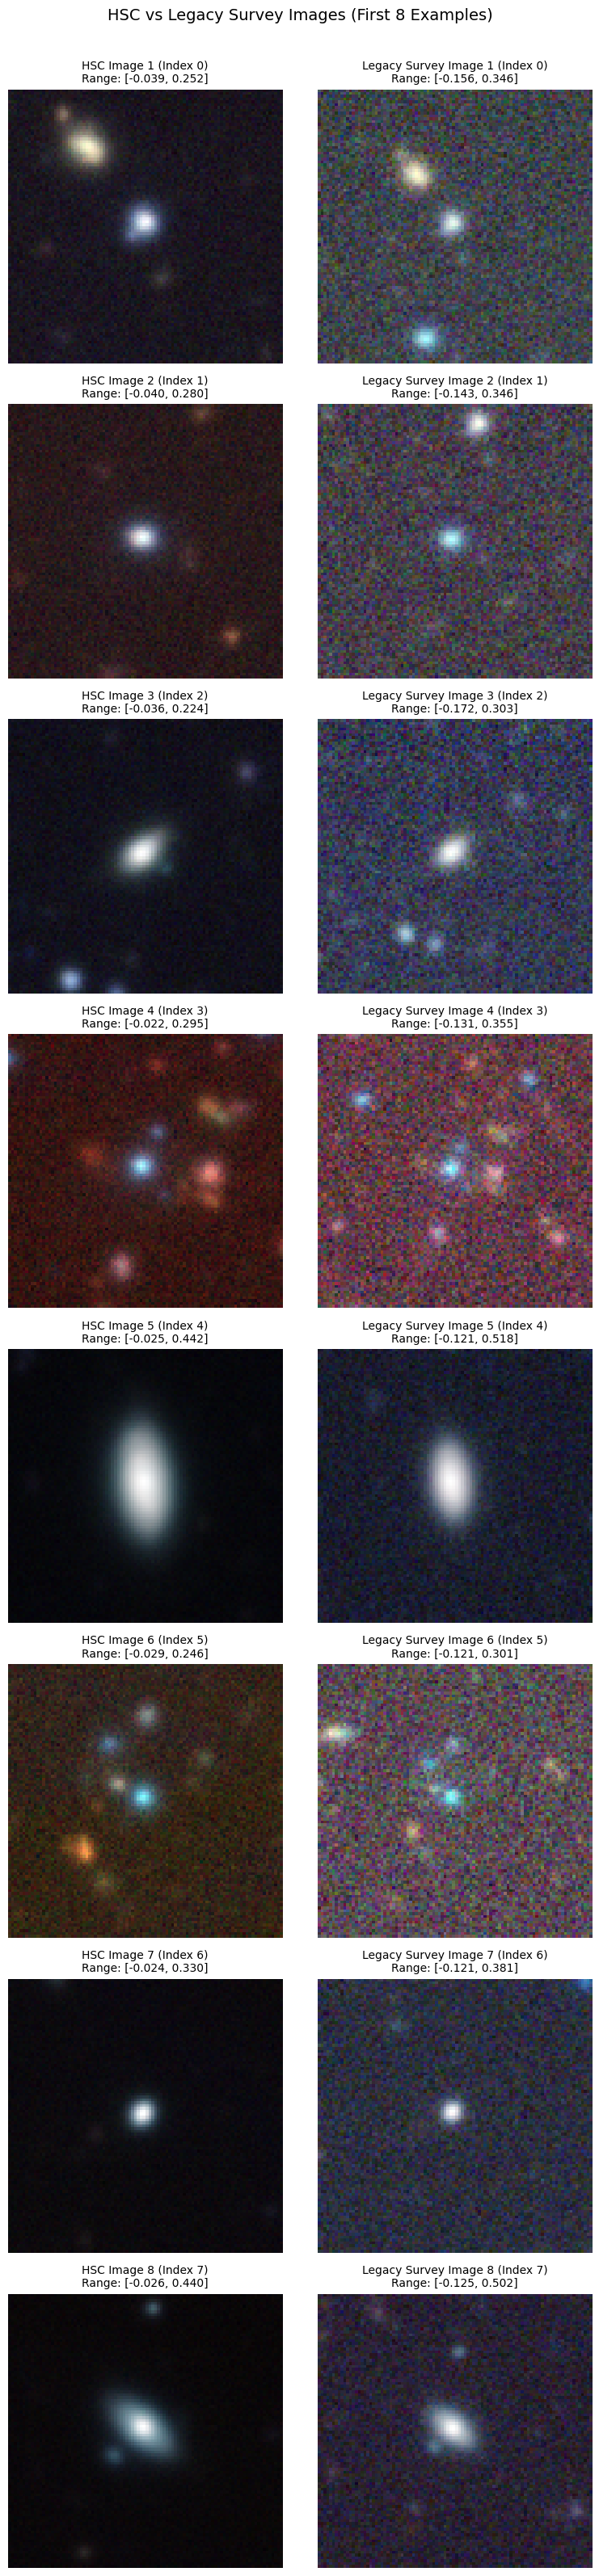

In [12]:
# Visualize HSC and Legacy images side by side
fig, axes = plt.subplots(num_examples, 2, figsize=(8, 4 * num_examples))

for i in range(num_examples):
    # HSC image
    hsc_rgb = convert_to_rgb(hsc_images[i])  # (96, 96, 3)
    axes[i, 0].imshow(hsc_rgb, vmin=0, vmax=1)
    axes[i, 0].set_title(f'HSC Image {i+1} (Index {indices[i]})\n'
                         f'Range: [{hsc_images[i].min():.3f}, {hsc_images[i].max():.3f}]',
                         fontsize=10)
    axes[i, 0].axis('off')

    # Legacy Survey image
    legacy_rgb = convert_to_rgb(legacy_images[i])  # (96, 96, 3)
    axes[i, 1].imshow(legacy_rgb, vmin=0, vmax=1)
    axes[i, 1].set_title(f'Legacy Survey Image {i+1} (Index {indices[i]})\n'
                        f'Range: [{legacy_images[i].min():.3f}, {legacy_images[i].max():.3f}]',
                        fontsize=10)
    axes[i, 1].axis('off')

plt.suptitle('HSC vs Legacy Survey Images (First 8 Examples)', fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()


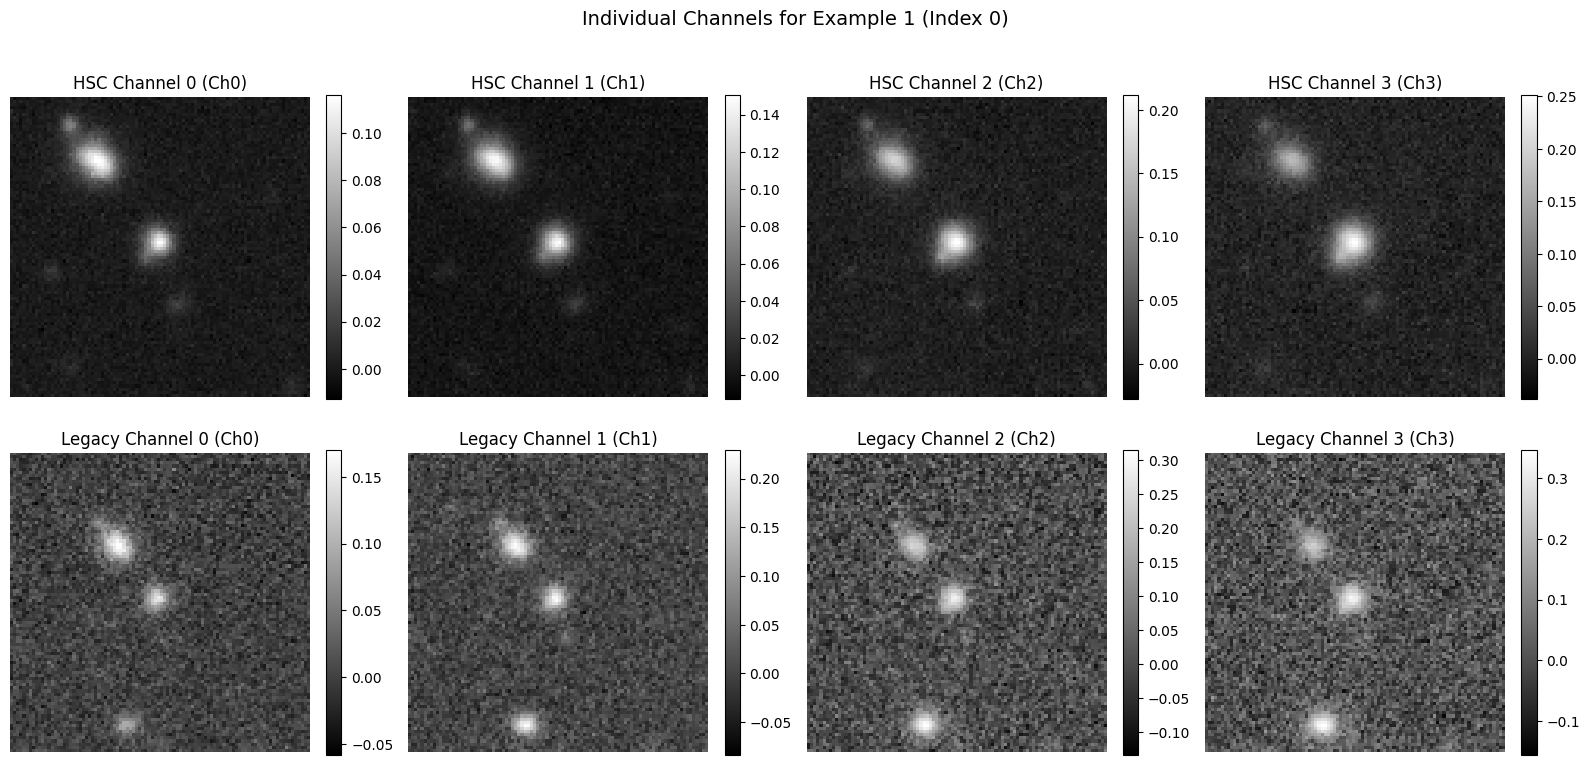

In [15]:
# Visualize individual channels for first example
example_idx = 0

# Reload metadata if needed (for standalone execution)
if 'hsc_bands' not in globals():
    with h5py.File(HDF5_PATH, 'r') as f:
        hsc_bands = f.attrs.get('hsc_bands', None)
        legacy_bands = f.attrs.get('legacy_bands', None)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# HSC channels
hsc_img = hsc_images[example_idx]  # (4, 96, 96)
hsc_band_list = hsc_bands.split(',') if hsc_bands else [f'Ch{i}' for i in range(4)]
for ch in range(4):
    im = axes[0, ch].imshow(hsc_img[ch], cmap='gray')
    axes[0, ch].set_title(f'HSC Channel {ch} ({hsc_band_list[ch]})')
    axes[0, ch].axis('off')
    plt.colorbar(im, ax=axes[0, ch], fraction=0.046)

# Legacy channels
legacy_img = legacy_images[example_idx]  # (4, 96, 96)
legacy_band_list = legacy_bands.split(',') if legacy_bands else [f'Ch{i}' for i in range(4)]
for ch in range(4):
    im = axes[1, ch].imshow(legacy_img[ch], cmap='gray')
    axes[1, ch].set_title(f'Legacy Channel {ch} ({legacy_band_list[ch]})')
    axes[1, ch].axis('off')
    plt.colorbar(im, ax=axes[1, ch], fraction=0.046)

plt.suptitle(f'Individual Channels for Example {example_idx+1} (Index {indices[example_idx]})',
             fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


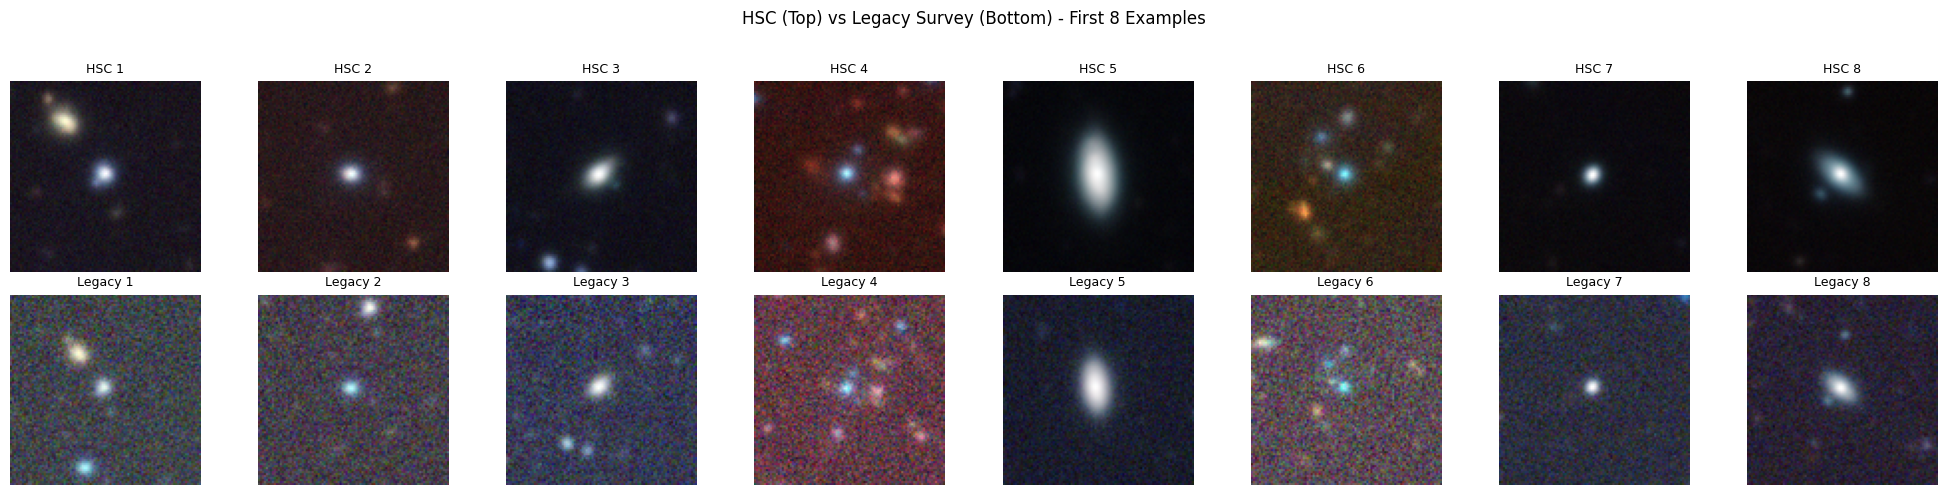

In [14]:
# Compare HSC and Legacy side by side in a grid
fig, axes = plt.subplots(2, num_examples, figsize=(2.5 * num_examples, 5))

for i in range(num_examples):
    # Top row: HSC images
    hsc_rgb = convert_to_rgb(hsc_images[i])
    axes[0, i].imshow(hsc_rgb, vmin=0, vmax=1)
    axes[0, i].set_title(f'HSC {i+1}', fontsize=9)
    axes[0, i].axis('off')

    # Bottom row: Legacy images
    legacy_rgb = convert_to_rgb(legacy_images[i])
    axes[1, i].imshow(legacy_rgb, vmin=0, vmax=1)
    axes[1, i].set_title(f'Legacy {i+1}', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('HSC (Top) vs Legacy Survey (Bottom) - First 8 Examples', fontsize=12, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
